<a href="https://colab.research.google.com/github/princesse85/sentiment/blob/main/final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk # Moved the import of nltk to the top

from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt')
stop_words = set(stopwords.words('english'))
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.metrics import accuracy_score, classification_report



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
train_dataset = pd.read_csv('/content/e commerce reviews test.csv')

In [10]:
test_dataset = pd.read_csv  ('/content/e commerce reviews test.csv')

In [11]:
# Sample review dataset (Replace with actual dataset)
data = {
    "review": [
        "I love this product! It's amazing.",
        "Terrible experience, I hate it!",
        "Great value for money. Highly recommend!",
        "Worst product ever. Waste of money.",
        "Absolutely fantastic! Works like a charm.",
        "I don't like it, not worth the price.",
        "Superb quality, very happy with it.",
        "Disappointed, not what I expected."
    ],
    "label": ["__label__2", "__label__1", "__label__2", "__label__1", "__label__2", "__label__1", "__label__2", "__label__1"]
}

In [19]:
# in mapping===>old value:new value
mapped_values = {
    "__label__1": "negative",
    "__label__2": "positive"
}


In [20]:
# Convert to DataFrame
df = pd.DataFrame(data)



In [21]:


#  Map Labels: "__label__1" → 0 (Negative), "__label__2" → 1 (Positive)
df['sentiment'] = df['label'].map({"__label__1": 0, "__label__2": 1})


In [22]:
train_dataset.head(10)

,labels,text
0,__label__2,Great CD: My lovely Pat has one of the GREAT v...
1,__label__2,One of the best game music soundtracks - for a...
2,__label__1,Batteries died within a year ...: I bought thi...
3,__label__2,"works fine, but Maha Energy is better: Check o..."
4,__label__2,Great for the non-audiophile: Reviewed quite a...
5,__label__1,DVD Player crapped out after one year: I also ...
6,__label__1,"Incorrect Disc: I love the style of this, but ..."
7,__label__1,DVD menu select problems: I cannot scroll thro...
8,__label__2,Unique Weird Orientalia from the 1930's: Exoti...
9,__label__1,"Not an ""ultimate guide"": Firstly,I enjoyed the..."


In [23]:
test_dataset.head(10)

,labels,text
0,__label__2,Great CD: My lovely Pat has one of the GREAT v...
1,__label__2,One of the best game music soundtracks - for a...
2,__label__1,Batteries died within a year ...: I bought thi...
3,__label__2,"works fine, but Maha Energy is better: Check o..."
4,__label__2,Great for the non-audiophile: Reviewed quite a...
5,__label__1,DVD Player crapped out after one year: I also ...
6,__label__1,"Incorrect Disc: I love the style of this, but ..."
7,__label__1,DVD menu select problems: I cannot scroll thro...
8,__label__2,Unique Weird Orientalia from the 1930's: Exoti...
9,__label__1,"Not an ""ultimate guide"": Firstly,I enjoyed the..."


In [24]:
#  Text Cleaning Function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\W', ' ', text)  # Remove special characters
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    return text

df['cleaned_review'] = df['review'].apply(clean_text)

In [25]:
#remove stopwords
#bag of words
#tfidf
from tqdm import tqdm
#
text ='this is an example with some stopwords, i love this product ,it is good'
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [26]:
#tokenize the split:split into list of words
words = nltk.word_tokenize(text)

words


['this',
 'is',
 'an',
 'example',
 'with',
 'some',
 'stopwords',
 ',',
 'i',
 'love',
 'this',
 'product',
 ',',
 'it',
 'is',
 'good']

In [27]:
filtered_words = [word for word in words if word not in stop_words]

In [40]:
filtered_words

['example', 'stopwords', ',', 'love', 'product', ',', 'good']

In [28]:
filtered_text = ' '.join(filtered_words)

In [42]:
filtered_text

'example stopwords , love product , good'

In [29]:
def remove_stopwords(text):

  words = nltk.word_tokenize(text)
  filtered_words = [word for word in words if word not in stop_words]
  filtered_text = ' '.join(filtered_words)
  return filtered_text

In [30]:
train_dataset['text'] .head(10).apply(remove_stopwords)

,text
0,Great CD : My lovely Pat one GREAT voices gene...
1,One best game music soundtracks - game I n't r...
2,Batteries died within year ... : I bought char...
3,"works fine , Maha Energy better : Check Maha E..."
4,Great non-audiophile : Reviewed quite bit comb...
5,DVD Player crapped one year : I also began inc...
6,"Incorrect Disc : I love style , couple years ,..."
7,DVD menu select problems : I scroll DVD menu s...
8,Unique Weird Orientalia 1930 's : Exotic tales...
9,"Not `` ultimate guide '' : Firstly , I enjoyed..."


In [14]:
train_dataset['text'].head(10)

,text
0,Great CD: My lovely Pat has one of the GREAT v...
1,One of the best game music soundtracks - for a...
2,Batteries died within a year ...: I bought thi...
3,"works fine, but Maha Energy is better: Check o..."
4,Great for the non-audiophile: Reviewed quite a...
5,DVD Player crapped out after one year: I also ...
6,"Incorrect Disc: I love the style of this, but ..."
7,DVD menu select problems: I cannot scroll thro...
8,Unique Weird Orientalia from the 1930's: Exoti...
9,"Not an ""ultimate guide"": Firstly,I enjoyed the..."


In [13]:
train_dataset

,labels,text
0,__label__2,Great CD: My lovely Pat has one of the GREAT v...
1,__label__2,One of the best game music soundtracks - for a...
2,__label__1,Batteries died within a year ...: I bought thi...
3,__label__2,"works fine, but Maha Energy is better: Check o..."
4,__label__2,Great for the non-audiophile: Reviewed quite a...
...,...,...
399995,__label__1,Unbelievable- In a Bad Way: We bought this Tho...
399996,__label__1,"Almost Great, Until it Broke...: My son reciev..."
399997,__label__1,Disappointed !!!: I bought this toy for my son...
399998,__label__2,Classic Jessica Mitford: This is a compilation...


In [48]:
# Split Data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(df['cleaned_review'], df['sentiment'], test_size=0.2, random_state=42)

In [47]:
# vectorizer

vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

X_train_tfidf shape: (4, 22)
X_test_tfidf shape: (2, 22)


In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer # Import TfidfVectorizer
import joblib
# Save the vectorizer
joblib.dump(TfidfVectorizer, "tfidf_vectorizer.pkl")

print(" TF-IDF Vectorizer saved successfully!")

 TF-IDF Vectorizer saved successfully!


In [38]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer # Import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Assuming df, clean_text are defined as in your previous code snippets

# Split Data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(df['cleaned_review'], df['sentiment'], test_size=0.2, random_state=42)


# Further split the training data into training and validation sets (e.g., 80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# TF-IDF Vectorization (Fit on training data only)
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform validation and test data using the fitted vectorizer
X_val_tfidf = vectorizer.transform(X_val)  # Now X_val_tfidf is defined
X_test_tfidf = vectorizer.transform(X_test)

# Train Logistic Regression Model
log_reg = LogisticRegression()
log_reg.fit(X_train_tfidf, y_train)
y_pred_log_reg = log_reg.predict(X_val_tfidf)
print("Logistic Regression Accuracy:", accuracy_score(y_val, y_pred_log_reg))
print(classification_report(y_val, y_pred_log_reg))

Logistic Regression Accuracy: 0.5
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [41]:
# 3️⃣ Support Vector Machine (SVM)
svm_model = SVC(kernel='linear')
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)
print("Logistic Regression Accuracy:", accuracy_score(y_val, y_pred_log_reg))
print(classification_report(y_val, y_pred_log_reg))

Logistic Regression Accuracy: 0.5
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [54]:
# Import necessary libraries
from sklearn.ensemble import RandomForestClassifier  # Import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer # Import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


# Assuming df, clean_text are defined as in your previous code snippets

# Split Data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(df['cleaned_review'], df['sentiment'], test_size=0.2, random_state=42)


# Further split the training data into training and validation sets (e.g., 80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# TF-IDF Vectorization (Fit on training data only)
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform validation and test data using the fitted vectorizer
X_val_tfidf = vectorizer.transform(X_val)  # Now X_val_tfidf is defined
X_test_tfidf = vectorizer.transform(X_test)

# Train Faster Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=80,
    max_depth=8,
    min_samples_split=4,
    n_jobs=-1,
    random_state=38
)

#The line below is changed to fit the model on the same training dataset as the vectorizer
rf_model.fit(X_train_tfidf, y_train)
y_pred_rf = rf_model.predict(X_val_tfidf)

print("Random Forest Accuracy:", accuracy_score(y_val, y_pred_rf))
print(classification_report(y_val, y_pred_rf))

Random Forest Accuracy: 0.5
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [56]:
#saving the models for depolyment and future use
import joblib

# Save Logistic Regression Model
joblib.dump(log_reg, "logistic_regression_model.pkl")  # Changed log_model to log_reg

# Save Random Forest Model
joblib.dump(rf_model, "random_forest_model.pkl")

# Train and Save XGBoost Model
# Import the XGBoost classifier
from xgboost import XGBClassifier

# Create and train the XGBoost model
xgb_model = XGBClassifier()
xgb_model.fit(X_train_tfidf, y_train)

# Now save the XGBoost model
joblib.dump(xgb_model, "xgboost_model.pkl")

print(" All models saved successfully as `.pkl` files!")

 All models saved successfully as `.pkl` files!


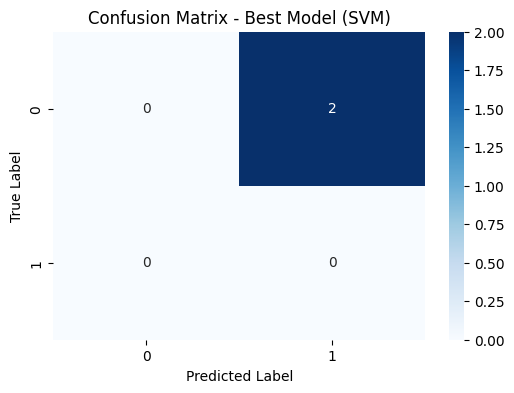

In [55]:
#  Plot Confusion Matrix for Best Model
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, best_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix - Best Model ({best_model})")
plt.show()

In [56]:
nltk.download('vader_lexicon')

from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    # Get polarity scores using VADER
    scores = sia.polarity_scores(text)
    # Classify as positive or negative based on compound score
    if scores['compound'] >= 0.05:
        return 1  # Positive
    else:
        return 0  # Negative
        print(f"The sentiment is {sentiment} (Compound Score: {compound_score})")








[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [57]:
#getting the sentiment scores
# Initialize sentiment_scores with an example text
example_text = "This is an example sentence."  # Replace with your desired text
sentiment_scores = sia.polarity_scores(example_text)

compound_score = sentiment_scores['compound']
#now lets make a decision for the cut off for a postitive or negative score
if compound_score > 0:
    sentiment = "Positive"
else:
  sentiment = "Negative"

print(f"The sentiment is {sentiment} (Compound Score: {compound_score})")

The sentiment is Positive (Compound Score: 0.0772)


In [58]:
##we want to apply all we just did to all the text in our dataset, so lets first
##create the function, then we apply the function

def analyze_sentence(sentence, threshold = 0):
  sentiment_scores = analyzer.polarity_scores(sentence)
  compound_score = sentiment_scores['compound']

  if compound_score > threshold:
    sentiment = "positive"
  else:
    sentiment = "negative"

  return sentiment

In [66]:
total_rows = len(test_dataset)
tqdm.pandas(total=total_rows)

In [61]:
total_rows = len(train_dataset)
tqdm.pandas(total=total_rows)
# Replacing 'get_stopwords' with 'remove_stopwords' to use the defined function
train_dataset['stop words']= train_dataset['text'].progress_apply(remove_stopwords)

100%|██████████| 400000/400000 [05:21<00:00, 1245.29it/s]


In [62]:
train_dataset

,labels,text,stop words
0,__label__2,Great CD: My lovely Pat has one of the GREAT v...,Great CD : My lovely Pat one GREAT voices gene...
1,__label__2,One of the best game music soundtracks - for a...,One best game music soundtracks - game I n't r...
2,__label__1,Batteries died within a year ...: I bought thi...,Batteries died within year ... : I bought char...
3,__label__2,"works fine, but Maha Energy is better: Check o...","works fine , Maha Energy better : Check Maha E..."
4,__label__2,Great for the non-audiophile: Reviewed quite a...,Great non-audiophile : Reviewed quite bit comb...
...,...,...,...
399995,__label__1,Unbelievable- In a Bad Way: We bought this Tho...,Unbelievable- In Bad Way : We bought Thomas so...
399996,__label__1,"Almost Great, Until it Broke...: My son reciev...","Almost Great , Until Broke ... : My son reciev..."
399997,__label__1,Disappointed !!!: I bought this toy for my son...,Disappointed ! ! ! : I bought toy son loves ``...
399998,__label__2,Classic Jessica Mitford: This is a compilation...,Classic Jessica Mitford : This compilation wid...


from matplotlib import pyplot as plt
import seaborn as sns
train_dataset.groupby('labels').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

In [63]:
# Add the 'stop words' column to test_dataset using the same method as train_dataset
 # Calculate total rows for test_dataset
total_rows = len(test_dataset)
tqdm.pandas(total=total_rows)
# Apply remove_stopwords to test_datase
test_dataset['stop words'] = test_dataset['text'].progress_apply(remove_stopwords)



100%|██████████| 400000/400000 [04:41<00:00, 1419.24it/s]


In [64]:
# Apply VADER sentiment analysis to the 'text' column and store results in 'vader_on_text'
test_dataset['vader_on_text'] = test_dataset['text'].apply(get_vader_sentiment)




In [89]:
def evaluate(model, dataloader):
    model.eval()
    predictions, true_labels = [], []

    with torch.no_grad():
        for batch in dataloader:
            input_ids, attention_mask, labels = [b.to(device) for b in batch]

            outputs = model(input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()

            predictions.extend(preds)
            true_labels.extend(labels.cpu().numpy())

    return predictions, true_labels
    plt.show()

In [57]:
%%writefile app.py
import streamlit as st
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split


# Load the model
with open('sentiment_model.pkl', 'rb') as f:
    sentiment_model = pickle.load(f)

# Load the vectorizer
with open('tfidf_vectorizer.pkl', 'rb') as f:
    tfidf_vectorizer = pickle.load(f)

st.title("Ecommerce Customer Reviews Sentiment Analysis App")


st.write("""
        Welcome to our Ecommerce Customer Reviews Analysis App.
        This simple tool analyzes customer reviews to show you the sentiment
        content of the review.
        It uses machine learning to quickly highlight positive and negative
         feedback, helping you make better business decisions.""")


# Text input
user_input = st.text_area("Input The Text That You Want Analyzed Down Below: ",
                          height=100)


# Prediction button
if st.button("Predict"):
    # Transform user input to TF-IDF features
    input_features = tfidf_vectorizer.transform([user_input])
    #  Predict sentiment
    prediction = sentiment_model.predict(input_features)

    # Display the result
    st.write(f"The Text inputed is a ", prediction[0] , "Sentiment")


Writing app.py


In [ ]:
!curl htt